In [122]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
print ("Models imported successfully✅")

Models imported successfully✅


In [123]:
EB_data = pd.read_csv(r"C:\Users\hp\Downloads\electricity_daily_9years_household.csv")

In [124]:
EB_data.head(10)

,Date,Household_ID,AC_Hours,Fridge_Hours,Heater_Hours,Fan_Hours,Light_Hours,NightLamp_Hours,LEDBulb_Hours,TV_Hours,WashingMachine_Hours,Chimney_Hours,Mixer_Hours,Grinder_Hours,InductionStove_Hours,Daily_kWh,Monthly_Units,Price_Rs
0,01-01-2017,MTR100234,2.18,24.0,1.04,4.88,5.22,7.90,5.83,1.67,0.68,1.09,0.09,0.00,0.00,9.81,9.81,53.96
1,01-02-2017,MTR100234,0.59,24.0,2.16,4.75,5.57,8.02,5.55,5.03,0.00,0.58,0.30,0.00,0.77,11.22,21.03,115.66
2,01-03-2017,MTR100234,5.75,24.0,1.63,5.17,3.51,8.34,5.17,2.40,0.00,0.41,0.00,0.30,0.00,15.90,36.93,203.12
3,01-04-2017,MTR100234,0.00,24.0,0.88,NaN,4.15,8.93,7.38,0.00,0.00,0.88,0.31,0.16,1.63,9.46,46.39,255.14
4,01-05-2017,MTR100234,2.56,24.0,0.00,3.22,6.21,9.53,7.43,1.14,0.00,0.86,0.15,0.16,0.00,7.87,54.26,298.43
5,01-06-2017,MTR100234,1.27,24.0,1.80,4.0,10.18,6.26,5.43,7.69,0.00,1.14,0.13,0.11,1.09,13.07,67.33,370.32
6,01-07-2017,MTR100234,0.93,24.0,1.88,4.13,4.89,7.39,4.09,5.27,0.00,0.00,0.25,0.07,1.66,12.59,79.92,439.56
7,01-08-2017,MTR100234,3.21,24.0,1.55,4.27,4.73,8.27,NaN,6.56,0.52,0.18,0.00,0.08,0.52,13.43,93.35,513.42
8,01-09-2017,MTR100234,0.00,24.0,1.71,2.34,5.46,8.17,6.79,2.18,0.00,0.00,0.10,0.00,0.00,6.87,100.22,551.43
9,01-10-2017,MTR100234,0.00,24.0,1.13,4.38,6.67,7.09,3.98,4.61,0.86,0.77,0.00,0.15,1.08,9.32,109.54,612.01


In [125]:
EB_data.drop(columns = ['Household_ID', 'Date'], inplace = True)

In [126]:
EB_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3269 entries, 0 to 3268
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   AC_Hours              3269 non-null   float64
 1   Fridge_Hours          3269 non-null   float64
 2   Heater_Hours          3269 non-null   float64
 3   Fan_Hours             3203 non-null   object 
 4   Light_Hours           3201 non-null   object 
 5   NightLamp_Hours       3204 non-null   float64
 6   LEDBulb_Hours         3201 non-null   object 
 7   TV_Hours              3269 non-null   float64
 8   WashingMachine_Hours  3204 non-null   float64
 9   Chimney_Hours         3269 non-null   float64
 10  Mixer_Hours           3204 non-null   float64
 11  Grinder_Hours         3204 non-null   float64
 12  InductionStove_Hours  3204 non-null   float64
 13  Daily_kWh             3269 non-null   float64
 14  Monthly_Units         3269 non-null   float64
 15  Price_Rs             

In [127]:
EB_data = EB_data.apply(pd.to_numeric, errors="coerce")

In [128]:
EB_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3269 entries, 0 to 3268
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   AC_Hours              3269 non-null   float64
 1   Fridge_Hours          3269 non-null   float64
 2   Heater_Hours          3269 non-null   float64
 3   Fan_Hours             3192 non-null   float64
 4   Light_Hours           3192 non-null   float64
 5   NightLamp_Hours       3204 non-null   float64
 6   LEDBulb_Hours         3192 non-null   float64
 7   TV_Hours              3269 non-null   float64
 8   WashingMachine_Hours  3204 non-null   float64
 9   Chimney_Hours         3269 non-null   float64
 10  Mixer_Hours           3204 non-null   float64
 11  Grinder_Hours         3204 non-null   float64
 12  InductionStove_Hours  3204 non-null   float64
 13  Daily_kWh             3269 non-null   float64
 14  Monthly_Units         3269 non-null   float64
 15  Price_Rs             

In [129]:
EB_data.shape

(3269, 16)

In [130]:
EB_data.isnull().sum()

AC_Hours                 0
Fridge_Hours             0
Heater_Hours             0
Fan_Hours               77
Light_Hours             77
NightLamp_Hours         65
LEDBulb_Hours           77
TV_Hours                 0
WashingMachine_Hours    65
Chimney_Hours            0
Mixer_Hours             65
Grinder_Hours           65
InductionStove_Hours    65
Daily_kWh                0
Monthly_Units            0
Price_Rs                 0
dtype: int64

In [131]:
EB_data.dropna(inplace=True)

In [132]:
EB_data.shape

(2757, 16)

In [133]:
EB_data.isnull().sum()

AC_Hours                0
Fridge_Hours            0
Heater_Hours            0
Fan_Hours               0
Light_Hours             0
NightLamp_Hours         0
LEDBulb_Hours           0
TV_Hours                0
WashingMachine_Hours    0
Chimney_Hours           0
Mixer_Hours             0
Grinder_Hours           0
InductionStove_Hours    0
Daily_kWh               0
Monthly_Units           0
Price_Rs                0
dtype: int64

In [134]:
hour_cols = EB_data.filter(like='_Hours').columns

(EB_data[hour_cols] < 0).sum()

AC_Hours                0
Fridge_Hours            0
Heater_Hours            0
Fan_Hours               5
Light_Hours             0
NightLamp_Hours         0
LEDBulb_Hours           0
TV_Hours                0
WashingMachine_Hours    0
Chimney_Hours           0
Mixer_Hours             0
Grinder_Hours           0
InductionStove_Hours    0
dtype: int64

In [135]:
EB_data = EB_data[(EB_data[hour_cols] >= 0).all(axis=1)]

In [136]:
(EB_data[hour_cols] < 0).sum()

AC_Hours                0
Fridge_Hours            0
Heater_Hours            0
Fan_Hours               0
Light_Hours             0
NightLamp_Hours         0
LEDBulb_Hours           0
TV_Hours                0
WashingMachine_Hours    0
Chimney_Hours           0
Mixer_Hours             0
Grinder_Hours           0
InductionStove_Hours    0
dtype: int64

In [137]:
EB_data.describe()

,AC_Hours,Fridge_Hours,Heater_Hours,Fan_Hours,Light_Hours,NightLamp_Hours,LEDBulb_Hours,TV_Hours,WashingMachine_Hours,Chimney_Hours,Mixer_Hours,Grinder_Hours,InductionStove_Hours,Daily_kWh,Monthly_Units,Price_Rs
count,2752.00000,2752.0,2752.000000,2752.000000,2752.000000,2752.000000,2752.000000,2752.000000,2752.000000,2752.000000,2752.000000,2752.000000,2752.000000,2752.000000,2752.000000,2752.000000
mean,4.70290,24.0,0.851562,7.913328,4.990872,8.001141,5.962478,4.002656,0.269876,0.473648,0.104433,0.082049,0.632602,15.172624,237.060461,1492.634578
std,2.74048,0.0,0.678350,3.182546,1.792964,1.448093,1.843444,1.788080,0.330889,0.356244,0.095215,0.093443,0.611461,6.086756,144.239631,984.210032
min,0.00000,24.0,0.000000,0.000000,0.000000,1.880000,0.430000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.500000,6.980000,38.390000
25%,2.63000,24.0,0.110000,5.697500,3.800000,7.057500,4.700000,2.787500,0.000000,0.097500,0.000000,0.000000,0.000000,12.040000,116.095000,654.622500
50%,4.57500,24.0,0.860000,8.030000,5.040000,8.010000,5.960000,3.950000,0.000000,0.490000,0.100000,0.040000,0.620000,14.850000,225.855000,1368.060000
75%,6.75000,24.0,1.380000,10.160000,6.180000,8.970000,7.210000,5.230000,0.580000,0.740000,0.180000,0.160000,1.120000,18.030000,338.610000,2168.862500
max,12.94000,24.0,2.820000,18.770000,11.560000,12.000000,12.000000,11.640000,1.250000,1.500000,0.410000,0.410000,2.670000,250.000000,803.510000,5630.270000


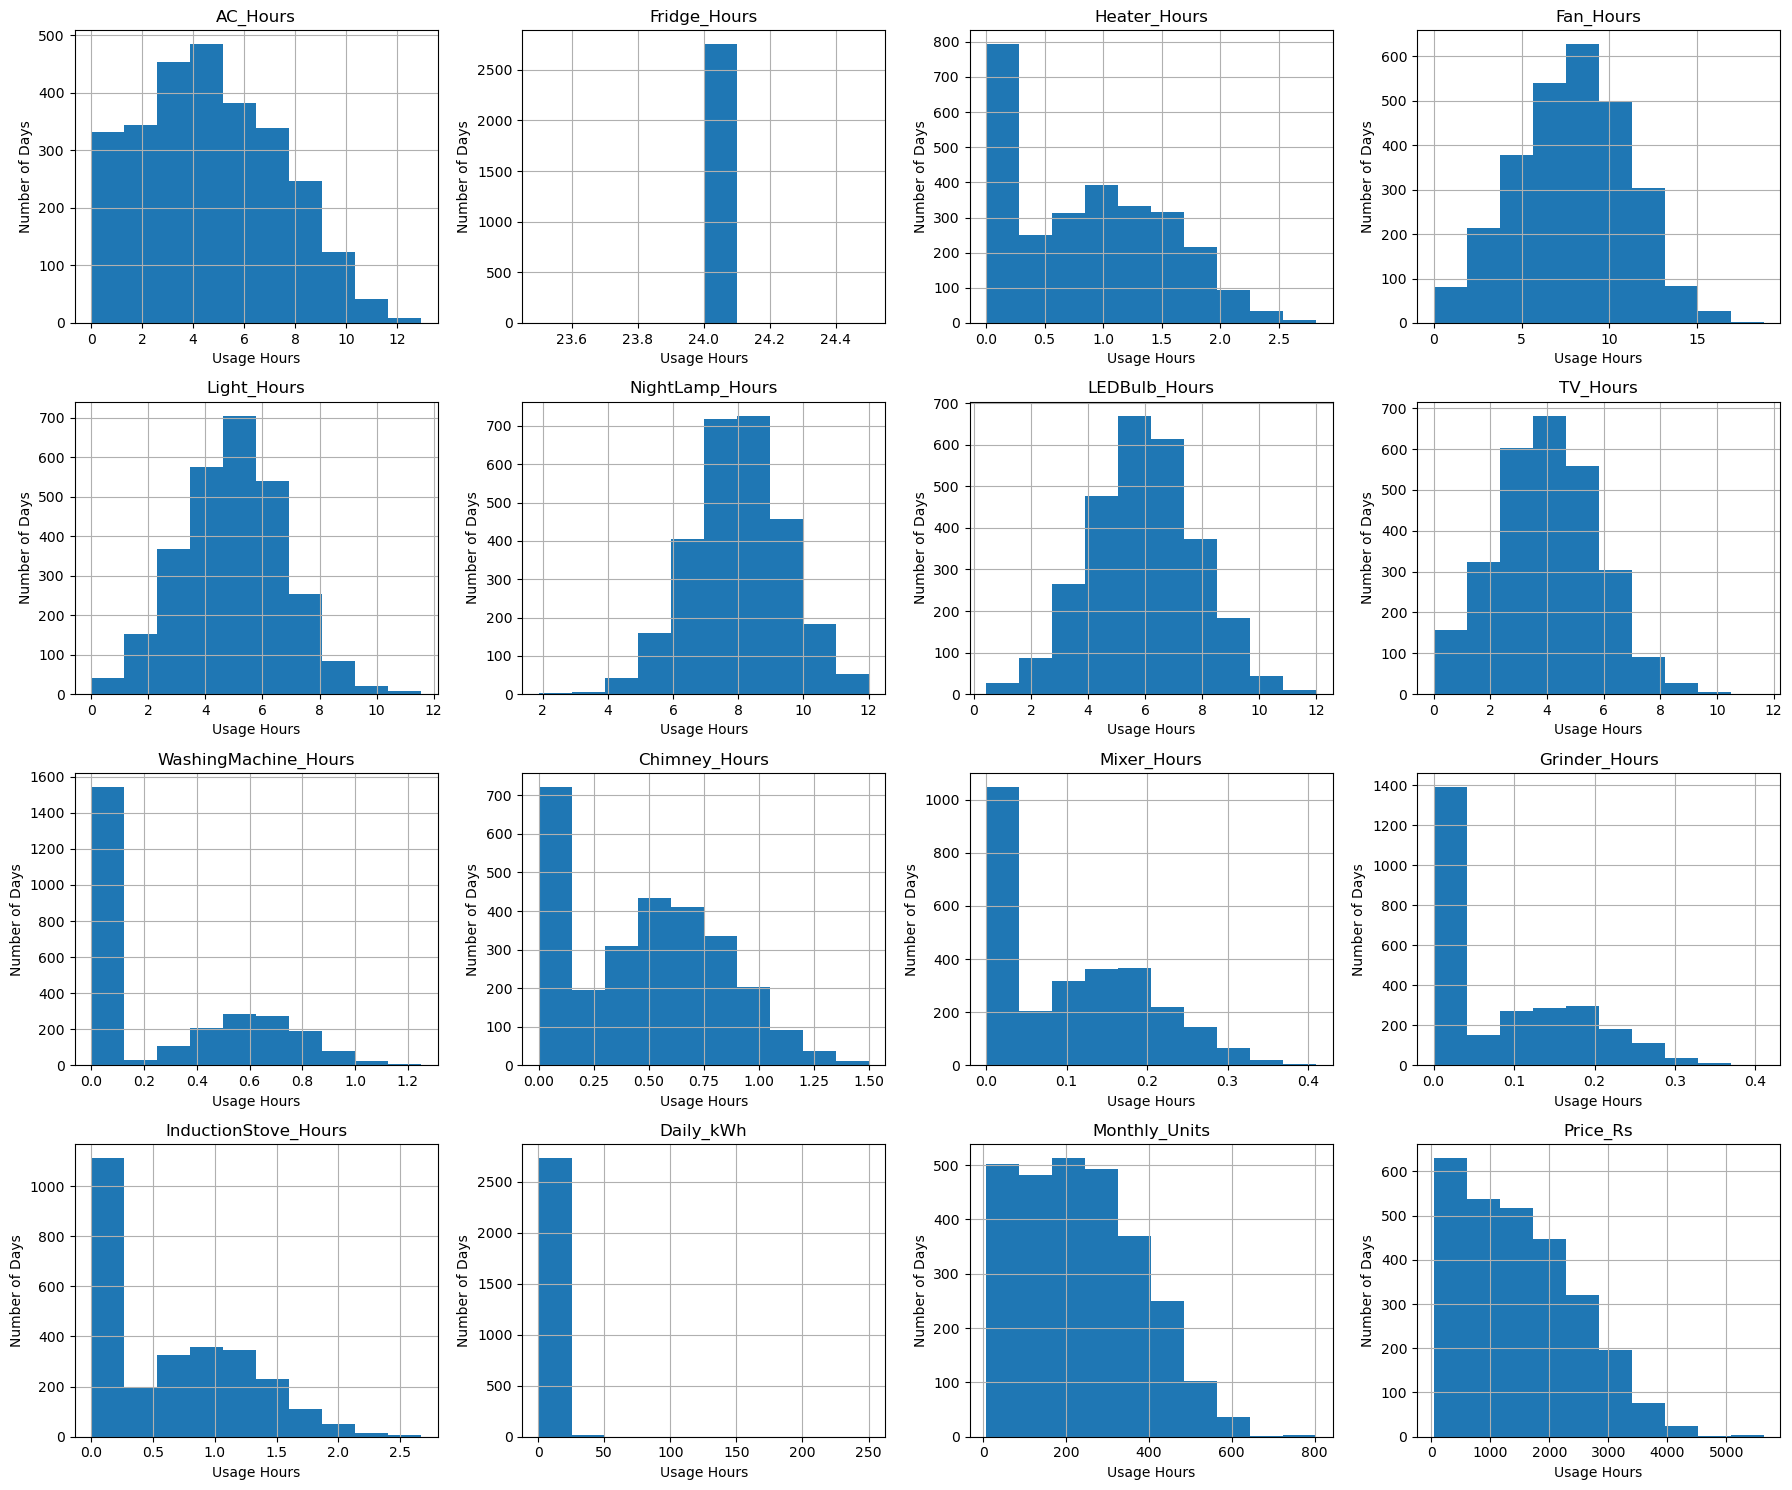

In [138]:
axes = EB_data.hist(figsize=(18,15))

for ax in axes.flatten():
    ax.set_xlabel("Usage Hours")
    ax.set_ylabel("Number of Days")

plt.tight_layout()
plt.show()

In [146]:
Q1 = EB_data['Daily_kWh'].quantile(0.25)
Q3 = EB_data['Daily_kWh'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Valid range: {lower_bound:.2f} to {upper_bound:.2f}")
print(f"Rows before: {len(EB_data)}")

EB_datan = EB_data[(EB_data['Daily_kWh'] >= lower_bound) & (EB_data['Daily_kWh'] <= upper_bound)]

print(f"Rows after: {len(EB_datan)}")

Valid range: 3.05 to 27.02
Rows before: 2752
Rows after: 2741


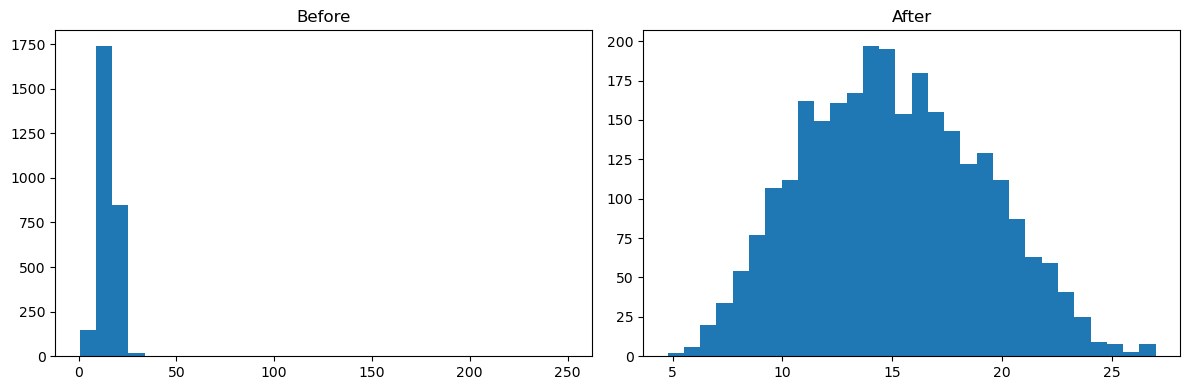

In [140]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.hist(EB_data['Daily_kWh'], bins=30)
plt.title("Before")

plt.subplot(1,2,2)
plt.hist(EB_datan['Daily_kWh'], bins=30)
plt.title("After")

plt.tight_layout()
plt.show()

In [141]:
EB_datan.columns

Index(['AC_Hours', 'Fridge_Hours', 'Heater_Hours', 'Fan_Hours', 'Light_Hours',
       'NightLamp_Hours', 'LEDBulb_Hours', 'TV_Hours', 'WashingMachine_Hours',
       'Chimney_Hours', 'Mixer_Hours', 'Grinder_Hours', 'InductionStove_Hours',
       'Daily_kWh', 'Monthly_Units', 'Price_Rs'],
      dtype='object')

In [153]:
x = EB_datan.drop(columns = ['Daily_kWh','Monthly_Units','Price_Rs'])
y = EB_datan['Daily_kWh']

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)
print("Train and Test data split successfully✅")
print ("Train size is ",x_train.shape)
print ("Test size is ",x_test.shape)

DS=StandardScaler()
x_trainscaled = DS.fit_transform(x_train)
x_testscaled = DS.transform(x_test)

Train and Test data split successfully✅
Train size is  (2192, 13)
Test size is  (549, 13)


In [156]:
model = LinearRegression()
model.fit(x_trainscaled, y_train)
print("Model trained successfully✅")

Model trained successfully✅


In [157]:
y_pred = model.predict(x_testscaled)
MAE = mean_absolute_error(y_test,y_pred)
MSE = mean_squared_error(y_test,y_pred)
RMSE = np.sqrt(MSE)
R2 = r2_score(y_test,y_pred)

print("Mean Absolute Error (MAE):", round(MAE, 2))
print("Mean Squared Error (MSE):", round(MSE, 2))
print("Root Mean Squared Error (RMSE):", round(RMSE, 2))
print("R-Squared (R2):", round(R2 * 100, 2), "%")

Mean Absolute Error (MAE): 0.0
Mean Squared Error (MSE): 0.0
Root Mean Squared Error (RMSE): 0.0
R-Squared (R2): 100.0 %


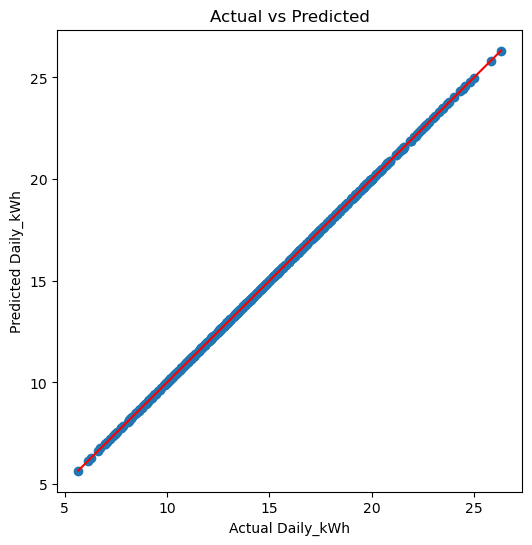

In [145]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)
plt.xlabel("Actual Daily_kWh")
plt.ylabel("Predicted Daily_kWh")
plt.title("Actual vs Predicted")
plt.show()

In [ ]:
import calendar

year = int(input("Enter Year: "))
month = int(input("Enter Month (1-12): "))

days = calendar.monthrange(year, month)[1]

feature_names = [
    'AC_Hours', 'Fridge_Hours', 'Heater_Hours', 'Fan_Hours',
    'Light_Hours', 'NightLamp_Hours', 'LEDBulb_Hours', 'TV_Hours',
    'WashingMachine_Hours', 'Chimney_Hours', 'Mixer_Hours',
    'Grinder_Hours', 'InductionStove_Hours'
]

user_values = []
for feature in feature_names:
    user_values.append(float(input(f"Enter {feature}: ")))

daily_kwh = model.predict([user_values])[0]

monthly_units = daily_kwh * days

if monthly_units <= 100:
    bill = monthly_units * 5.5 + 120
elif monthly_units <= 250:
    bill = (100 * 5.5) + (monthly_units - 100) * 6.5 + 120
else:
    bill = (100 * 5.5) + (150 * 6.5) + (monthly_units - 250) * 7.2 + 120

print("\n----- Prediction Result -----")
print(f"Daily kWh       : {daily_kwh:.2f}")
print(f"Monthly Units   : {monthly_units:.2f}")
print(f"Estimated Bill  : ₹{bill:.2f}")


----- Prediction Result -----
Daily kWh       : 55.85
Monthly Units   : 1731.31
Estimated Bill  : ₹12310.42
